In [86]:
%pip install seaborn



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [87]:
# INVESTIGATION 1
#description :it is the dataset is of a hotel booking used from diff hotels there fore we are gonna
#work on understanding why there are decrease in booking and so on

# INVESTIGATION 1
description :it is the dataset is of a hotel booking used from diff hotels there fore we are gonna
             work on understanding why there are decrease in booking and so on

it has 44010 rows and 37 columns


In [88]:
#description
import pandas as pd
import numpy as np
df=pd.read_csv("C:/-----SEM4-----/projects/data eng/StayEase_Cleaned_Dataset.csv")
#now to check no of rows or coloumn we gotta use df.head() it usually gives first 5 rows starting from 0
df.head()



,hotel_type,booking_status,advance_booking_days,arrival_year,arrival_month,arrival_week,arrival_day,weekend_nights,weekday_nights,num_adults,...,avg_daily_rate,parking_spaces,special_requests,reservation_status,reservation_date,total_stay_nights,booking_season,family_booking,total_guests,is_long_stay
0,Luxury Resort,1,2,2016,June,24,5,1,0,2,...,109.0,0,1,Cancelled,04-06-2016,1.0,Summer,0.0,2.0,0.0
1,Urban Hotel,1,82,2016,September,38,15,0,3,2,...,149.4,0,1,Cancelled,12-09-2016,3.0,Autumn,0.0,2.0,0.0
2,Luxury Resort,0,62,2015,August,34,20,2,8,2,...,104.0,0,0,Checked-Out,30-08-2015,10.0,Summer,0.0,2.0,1.0
3,Urban Hotel,0,133,2016,May,21,17,0,3,2,...,105.3,0,0,Checked-Out,20-05-2016,3.0,Spring,0.0,2.0,0.0
4,Luxury Resort,1,87,2016,August,33,12,1,2,2,...,204.0,0,0,Cancelled,02-06-2016,3.0,Summer,1.0,3.0,0.0


In [89]:
df.shape

(44010, 37)

In [90]:
df.describe()
#just to understand the data  i meaan the total count or mean or std we can get it from .describe()

,booking_status,advance_booking_days,arrival_year,arrival_week,arrival_day,weekend_nights,weekday_nights,num_adults,num_children,num_infants,...,modifications,travel_agent_id,waiting_days,avg_daily_rate,parking_spaces,special_requests,total_stay_nights,family_booking,total_guests,is_long_stay
count,44010.000000,44010.000000,44010.000000,44010.000000,44010.000000,44010.000000,44010.000000,44010.000000,44010.000000,44010.000000,...,44010.000000,36829.000000,44010.000000,44010.000000,44010.000000,44010.000000,44009.000000,44009.000000,44009.000000,44009.000000
mean,0.331175,94.928471,2016.179664,26.959100,15.724222,0.957055,2.529243,1.861418,0.112793,0.008703,...,0.238128,88.932309,1.658100,104.472886,0.068871,0.626380,3.486287,0.085437,1.981776,0.126633
std,0.470641,100.572661,0.702268,13.456067,8.742672,1.002676,1.942625,0.488589,0.414360,0.102200,...,0.661240,111.786207,15.280731,45.786097,0.254579,0.812734,2.606468,0.279534,0.668135,0.332565
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,15.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,0.000000,9.000000,0.000000,73.522500,0.000000,0.000000,2.000000,0.000000,2.000000,0.000000
50%,0.000000,61.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,...,0.000000,13.000000,0.000000,97.000000,0.000000,0.000000,3.000000,0.000000,2.000000,0.000000
75%,1.000000,147.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,...,0.000000,240.000000,0.000000,127.000000,0.000000,1.000000,4.000000,0.000000,2.000000,0.000000
max,1.000000,709.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,3.000000,10.000000,9.000000,...,17.000000,535.000000,391.000000,256.500000,3.000000,5.000000,69.000000,1.000000,4.000000,1.000000


In [91]:
#now lets drop any duplicates if it exists
df.drop_duplicates()
df.head(2)

,hotel_type,booking_status,advance_booking_days,arrival_year,arrival_month,arrival_week,arrival_day,weekend_nights,weekday_nights,num_adults,...,avg_daily_rate,parking_spaces,special_requests,reservation_status,reservation_date,total_stay_nights,booking_season,family_booking,total_guests,is_long_stay
0,Luxury Resort,1,2,2016,June,24,5,1,0,2,...,109.0,0,1,Cancelled,04-06-2016,1.0,Summer,0.0,2.0,0.0
1,Urban Hotel,1,82,2016,September,38,15,0,3,2,...,149.4,0,1,Cancelled,12-09-2016,3.0,Autumn,0.0,2.0,0.0


In [92]:
import numpy as np

#classification: now let us segregate them into numeric and names type
numeric= df.select_dtypes(include=['int64','float64']).columns.to_numpy
names= df.select_dtypes(include=['object','category']).columns.to_numpy
print("numeric types are: ",np.array(numeric))
print("name types are: ",np.array(names))


numeric types are:  <bound method IndexOpsMixin.to_numpy of Index(['booking_status', 'advance_booking_days', 'arrival_year',
       'arrival_week', 'arrival_day', 'weekend_nights', 'weekday_nights',
       'num_adults', 'num_children', 'num_infants', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'modifications', 'travel_agent_id', 'waiting_days', 'avg_daily_rate',
       'parking_spaces', 'special_requests', 'total_stay_nights',
       'family_booking', 'total_guests', 'is_long_stay'],
      dtype='object')>
name types are:  <bound method IndexOpsMixin.to_numpy of Index(['hotel_type', 'arrival_month', 'meal_plan', 'guest_country',
       'booking_segment', 'booking_channel', 'reserved_room', 'assigned_room',
       'deposit_type', 'corporate_id', 'customer_category',
       'reservation_status', 'reservation_date', 'booking_season'],
      dtype='object')>


In [93]:
#now lets check for 
for col in df.columns:
    unique_count = df[col].nunique()
    total_count = len(df)
    missing_count = df[col].isna().sum()
    
    print(f"Column: '{col}'")
    print(f"  - Unique values: {unique_count} out of {total_count}")
    print(f"  - Missing values: {missing_count}\n")
#apparently there are no unique values therfore we can find a primary key but we can find combinations of uniqueness


Column: 'hotel_type'
  - Unique values: 2 out of 44010
  - Missing values: 0

Column: 'booking_status'
  - Unique values: 2 out of 44010
  - Missing values: 0

Column: 'advance_booking_days'
  - Unique values: 469 out of 44010
  - Missing values: 0

Column: 'arrival_year'
  - Unique values: 3 out of 44010
  - Missing values: 0

Column: 'arrival_month'
  - Unique values: 12 out of 44010
  - Missing values: 0

Column: 'arrival_week'
  - Unique values: 53 out of 44010
  - Missing values: 0

Column: 'arrival_day'
  - Unique values: 31 out of 44010
  - Missing values: 0

Column: 'weekend_nights'
  - Unique values: 14 out of 44010
  - Missing values: 0

Column: 'weekday_nights'
  - Unique values: 29 out of 44010
  - Missing values: 0

Column: 'num_adults'
  - Unique values: 4 out of 44010
  - Missing values: 0

Column: 'num_children'
  - Unique values: 5 out of 44010
  - Missing values: 0

Column: 'num_infants'
  - Unique values: 4 out of 44010
  - Missing values: 0

Column: 'meal_plan'
  - 

# problems:
hmm what can be the problems before analysing:
1. maybe duplicate columns/rows
2. many missing value can also be a problem
3. similar names 
4. since its bookings instead of classifying different booking of a single person into one person label
   there is chance of making it seperate labels and unwanted lookupt or wrong lookup would lead to wrong calculations
5. as of now i couldnt find the primary key as there no distinct values for any column hence we could have      composite  keys

# investigation 2

In [94]:
df.info()
#yes we can say the data is useful as it has the required metrics such as booking status,is_repeated_guest
#previous cancellations, why it is cancellations so ye with these info we can get the insights of our required questions

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44010 entries, 0 to 44009
Data columns (total 37 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel_type                      44010 non-null  object 
 1   booking_status                  44010 non-null  int64  
 2   advance_booking_days            44010 non-null  int64  
 3   arrival_year                    44010 non-null  int64  
 4   arrival_month                   44010 non-null  object 
 5   arrival_week                    44010 non-null  int64  
 6   arrival_day                     44010 non-null  int64  
 7   weekend_nights                  44010 non-null  int64  
 8   weekday_nights                  44010 non-null  int64  
 9   num_adults                      44010 non-null  int64  
 10  num_children                    44010 non-null  float64
 11  num_infants                     44010 non-null  int64  
 12  meal_plan                       

In [95]:
#lets check again wether there are any knull values
howmany = df.isnull().sum()
print('null okvnn:', howmany)
#yes as we can see there are not much null values except for travel_Agentid 7181 
#so ye if there are  null values the good things is to do is to completely remove them or find a mean/median fill
# those missig values since this is a unique id i guess or i personally prefer to remove it completely

null okvnn: hotel_type                           0
booking_status                       0
advance_booking_days                 0
arrival_year                         0
arrival_month                        0
arrival_week                         0
arrival_day                          0
weekend_nights                       0
weekday_nights                       0
num_adults                           0
num_children                         0
num_infants                          0
meal_plan                            0
guest_country                        0
booking_segment                      0
booking_channel                      0
is_repeated_guest                    0
previous_cancellations               0
previous_bookings_not_canceled       0
reserved_room                        0
assigned_room                        0
modifications                        0
deposit_type                         0
travel_agent_id                   7181
corporate_id                         0
waiting_days 

In [96]:
#as said before other issue cany be duplicate rows or columns aas when we say there were no duplicate columns
print("duplicate rows: ",df.duplicated().sum())
#yes bad thing there are duplicate rows 
#problem: when we wanna calculate a price of the booking and when we query it there is a chance that the caluclation
#         of it would be increased than needed  which could eventually lead to wrong insights of the analysis


duplicate rows:  4607


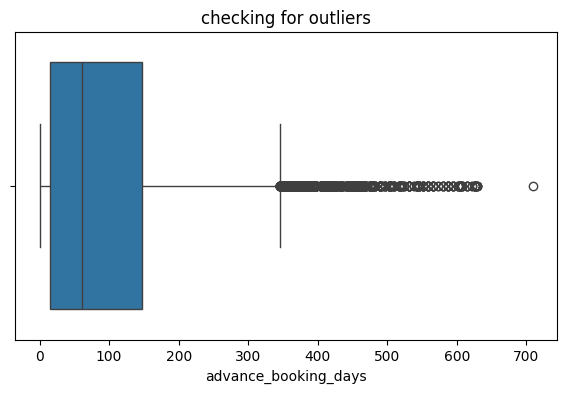

In [97]:
#the other issue would be outliers
#problem : if outliers are more that indicates that quality of the data is not good enough and we need to preprocess it more
#          if less that indicates the quality is good enough to be tested on and get conclusions
#          to be honest we cant just say good or bad data it depends on what we want 
#sol: first we need to calculate interquartile range and decide depending on fixed range iqr=q3-q1
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7,4))
sns.boxplot(x=df["advance_booking_days"])
plt.title("checking for outliers")
plt.show()

1. since this adavanced booking is left skewed usually we take median/etc etc
2. similary we can check the outliers for each coloumn that are mandatory and conclude it 
3. here we can say that advaced booking happend like 100 days or 200 days before which valid
   also we can see that there are outlier in 400 days or 500 like which is more than year before
   me personally think it is not possible like it is but not at the same 
   -- hence i would remove it.

# Investigation 3
i guess splitting the data into training and testing as learned 80 percent and 20 percent rule or anything depending on it

In [98]:
df.duplicated().sum()

np.int64(4607)

In [99]:
dfcl=df.copy()
#now this is the working set
dfcl.shape

(44010, 37)

In [100]:
#1. lets go through the null values again and check what we can do with it
dfcl.isnull().sum()


hotel_type                           0
booking_status                       0
advance_booking_days                 0
arrival_year                         0
arrival_month                        0
arrival_week                         0
arrival_day                          0
weekend_nights                       0
weekday_nights                       0
num_adults                           0
num_children                         0
num_infants                          0
meal_plan                            0
guest_country                        0
booking_segment                      0
booking_channel                      0
is_repeated_guest                    0
previous_cancellations               0
previous_bookings_not_canceled       0
reserved_room                        0
assigned_room                        0
modifications                        0
deposit_type                         0
travel_agent_id                   7181
corporate_id                         0
waiting_days             

In [101]:
#just like before we can see null values allot in travel agent id 
#so all those null values we can assume just asume by thinking that people checked in through without a travel agent
#this im saying thAt this might be not exactly this
dfcl['travel_agent_id']=dfcl['travel_agent_id'].fillna(0)
dfcl.isnull().sum()
#so yes we have given the value of no travel agent as 0

hotel_type                        0
booking_status                    0
advance_booking_days              0
arrival_year                      0
arrival_month                     0
arrival_week                      0
arrival_day                       0
weekend_nights                    0
weekday_nights                    0
num_adults                        0
num_children                      0
num_infants                       0
meal_plan                         0
guest_country                     0
booking_segment                   0
booking_channel                   0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room                     0
assigned_room                     0
modifications                     0
deposit_type                      0
travel_agent_id                   0
corporate_id                      0
waiting_days                      0
customer_category                 0
avg_daily_rate              

In [102]:
dfcl[dfcl.isnull().any(axis=1)]

,hotel_type,booking_status,advance_booking_days,arrival_year,arrival_month,arrival_week,arrival_day,weekend_nights,weekday_nights,num_adults,...,avg_daily_rate,parking_spaces,special_requests,reservation_status,reservation_date,total_stay_nights,booking_season,family_booking,total_guests,is_long_stay
44009,Urban Hotel,0,46,2016,September,37,5,1,3,3,...,186.77,0,1,Checked-Out,NaN,NaN,NaN,NaN,NaN,NaN


In [103]:
dfcl=dfcl.dropna()
dfcl.isnull().sum()


hotel_type                        0
booking_status                    0
advance_booking_days              0
arrival_year                      0
arrival_month                     0
arrival_week                      0
arrival_day                       0
weekend_nights                    0
weekday_nights                    0
num_adults                        0
num_children                      0
num_infants                       0
meal_plan                         0
guest_country                     0
booking_segment                   0
booking_channel                   0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room                     0
assigned_room                     0
modifications                     0
deposit_type                      0
travel_agent_id                   0
corporate_id                      0
waiting_days                      0
customer_category                 0
avg_daily_rate              

ok now all the NULL/NAN VALUES HAS BEEN DEALED NOOW LETS CHECK ON DUPLICATES


In [104]:
print(dfcl.duplicated())
#but before going first we have to check wether this duplicates are useful or not 

0        False
1        False
2        False
3        False
4        False
         ...  
44004    False
44005    False
44006    False
44007    False
44008    False
Length: 44009, dtype: bool


In [105]:
print( dfcl.columns)

Index(['hotel_type', 'booking_status', 'advance_booking_days', 'arrival_year',
       'arrival_month', 'arrival_week', 'arrival_day', 'weekend_nights',
       'weekday_nights', 'num_adults', 'num_children', 'num_infants',
       'meal_plan', 'guest_country', 'booking_segment', 'booking_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room', 'assigned_room',
       'modifications', 'deposit_type', 'travel_agent_id', 'corporate_id',
       'waiting_days', 'customer_category', 'avg_daily_rate', 'parking_spaces',
       'special_requests', 'reservation_status', 'reservation_date',
       'total_stay_nights', 'booking_season', 'family_booking', 'total_guests',
       'is_long_stay'],
      dtype='object')


In [106]:
dfcl.dtypes

hotel_type                         object
booking_status                      int64
advance_booking_days                int64
arrival_year                        int64
arrival_month                      object
arrival_week                        int64
arrival_day                         int64
weekend_nights                      int64
weekday_nights                      int64
num_adults                          int64
num_children                      float64
num_infants                         int64
meal_plan                          object
guest_country                      object
booking_segment                    object
booking_channel                    object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room                      object
assigned_room                      object
modifications                       int64
deposit_type                       object
travel_agent_id                   

In [107]:
dfcl["reservation_date"]=pd.to_datetime(dfcl["reservation_date"],errors='coerce')
print(dfcl["reservation_date"].dtype)

datetime64[ns]


In [108]:
print("Negative advance booking days:",
      (dfcl["advance_booking_days"] < 0).sum())

print("Negative average daily rate:",
      (dfcl["avg_daily_rate"] < 0).sum())

print("Negative adults:",
      (dfcl["num_adults"] < 0).sum())

print("Negative children:",
      (dfcl["num_children"] < 0).sum())

print("Negative infants:",
      (dfcl["num_infants"] < 0).sum())

print("Zero total guests:",
      (dfcl["total_guests"] == 0).sum())

print("Negative stay nights:",
      (dfcl["total_stay_nights"] < 0).sum())

Negative advance booking days: 0
Negative average daily rate: 0
Negative adults: 0
Negative children: 0
Negative infants: 0
Zero total guests: 76
Negative stay nights: 0


In [ ]:
zero_guests = dfcl[dfcl["total_guests"] ==0]

zero_guests[
    ["num_adults", "num_children", "num_infants", "total_guests"]
].value_counts()

num_adults  num_children  num_infants  total_guests
2           0.0           0            2.0             29557
1           0.0           0            1.0              8298
3           0.0           0            3.0              2288
2           1.0           0            3.0              1603
            2.0           0            4.0              1342
            0.0           1            3.0               288
3           1.0           0            4.0               203
1           1.0           0            2.0               128
            2.0           0            3.0                58
2           1.0           1            4.0                50
3           0.0           0            4.0                30
2           3.0           0            4.0                28
3           2.0           0            4.0                23
2           2.0           1            4.0                14
1           0.0           1            2.0                 7
3           0.0           1      

In [ ]:
# 76 records contain zero adults, children and infants.
# Since a valid hotel stay requires at least one guest,
# these records are treated as invalid and removed.

dfcl = dfcl[dfcl["total_guests"] ==0]

In [119]:
print((dfcl["total_guests"] ==0).sum())

0


In [121]:
print("old rows:",df.shape)
print("new rows:",dfcl.shape)


old rows: (44010, 37)
new rows: (43933, 37)


In [113]:
#now lets work on outlier
outliers = dfcl[dfcl["advance_booking_days"]>629]
print(len(outliers))
#see i think that the idead would be max 1 year 4/5 months other than that would be possible but i dont think it makes sense
#ye so there is onyl one person who booked 629 days ago ~ 1.7 years

1


In [122]:
print("Final dataset shape:", dfcl.shape)

print("\nMissing values:")
print(dfcl.isnull().sum())

print("\nDuplicate-looking rows:")
print(dfcl.duplicated().sum())

print("\nZero guest bookings:")
print((dfcl["total_guests"] == 0).sum())

print("\nData types:")
print(dfcl.dtypes)

Final dataset shape: (43933, 37)

Missing values:
hotel_type                            0
booking_status                        0
advance_booking_days                  0
arrival_year                          0
arrival_month                         0
arrival_week                          0
arrival_day                           0
weekend_nights                        0
weekday_nights                        0
num_adults                            0
num_children                          0
num_infants                           0
meal_plan                             0
guest_country                         0
booking_segment                       0
booking_channel                       0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room                         0
assigned_room                         0
modifications                         0
deposit_type                          0
travel_agent_id               

The dataset was prepared for further analysis by handling missing values, correcting inappropriate data types, investigating duplicate-looking records, checking invalid values, and examining outliers. Missing travel agent IDs were treated as potentially representing bookings without a recorded agent, while the single incomplete record was removed. Records containing zero guests were removed as invalid. Identical rows were retained because the dataset does not contain a unique booking identifier, making it impossible to confirm whether they are true duplicates. Outliers in advance booking days were investigated using the IQR method and retained because extreme advance bookings remain realistically possible.

# INVESTIGATION 4
- now i need to check on costumer and booking behaviour by maybe graphs or so and give analysis
  of it ...ye lets see how it goes maybe first let mee segrgate costumer columns and booking columns


In [115]:
dfcl.columns
#num_adults , num_Children, num_infants , arrival
#questions,, how many adults, children , infants usually come maybe with family
# when do people usually come(like week days(weekday_nights), weekends(weekends_nights))
#how many people needed modifications (we need this so that if modifications is more we can change the hotel needs)
#total stay nights

Index(['hotel_type', 'booking_status', 'advance_booking_days', 'arrival_year',
       'arrival_month', 'arrival_week', 'arrival_day', 'weekend_nights',
       'weekday_nights', 'num_adults', 'num_children', 'num_infants',
       'meal_plan', 'guest_country', 'booking_segment', 'booking_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room', 'assigned_room',
       'modifications', 'deposit_type', 'travel_agent_id', 'corporate_id',
       'waiting_days', 'customer_category', 'avg_daily_rate', 'parking_spaces',
       'special_requests', 'reservation_status', 'reservation_date',
       'total_stay_nights', 'booking_season', 'family_booking', 'total_guests',
       'is_long_stay'],
      dtype='object')

In [ ]:
total= df["num_adults"].sum()+df["num_children"].sum()

#we are not counting infants
print("the total number of people: ", total)
print(f"number of adults: {df["num_adults"].sum()} / {total} ")
print(f"num of children: {df["num_children"].sum()} / {total} ")
weekday_adult = dfcl.loc[(dfcl["weekday_nights"]>0) & (dfcl["weekend_nights"]==0), "num_adults"].sum()
print("total number of weekday adults: ", weekday_adult)
weekend_adult = dfcl.loc[(dfcl["weekend_nights"]>0) & (dfcl["weekday_nights"]==0), "num_adults"].sum()
print("total number of weekday adults: ", weekend_adult)



the total number of people:  86885.0
number of adults: 81921 / 86885.0 
num of children: 4964.0 / 86885.0 
total number of weekday adults:  32827
total number of weekday adults:  4532
0


In [147]:
dfcl["total_stay_nights"].describe()

dfcl["family_booking"].value_counts()

dfcl["is_repeated_guest"].value_counts()

is_repeated_guest
0    42433
1     1500
Name: count, dtype: int64

In [150]:
print("Booking Channels:")
print(dfcl["booking_channel"].value_counts())

print("\nBooking Segments:")
print(dfcl["booking_segment"].value_counts())

print("\nDeposit Types:")
print(dfcl["deposit_type"].value_counts())

print("\nAdvance Booking Days:")
print(dfcl["advance_booking_days"].describe())

Booking Channels:
booking_channel
TA/TO        35550
Direct        5806
Corporate     2485
GDS             91
Undefined        1
Name: count, dtype: int64

Booking Segments:
booking_segment
Online TA         22853
Offline TA/TO      8138
Group Bookings     5367
Direct             5178
Corporate          2027
Complementary       279
Aviation             91
Name: count, dtype: int64

Deposit Types:
deposit_type
No Deposit    40624
Non Refund     3267
Refundable       42
Name: count, dtype: int64

Advance Booking Days:
count    43933.000000
mean        95.030547
std        100.597300
min          0.000000
25%         15.000000
50%         61.000000
75%        147.000000
max        709.000000
Name: advance_booking_days, dtype: float64


<Axes: xlabel='booking_channel'>

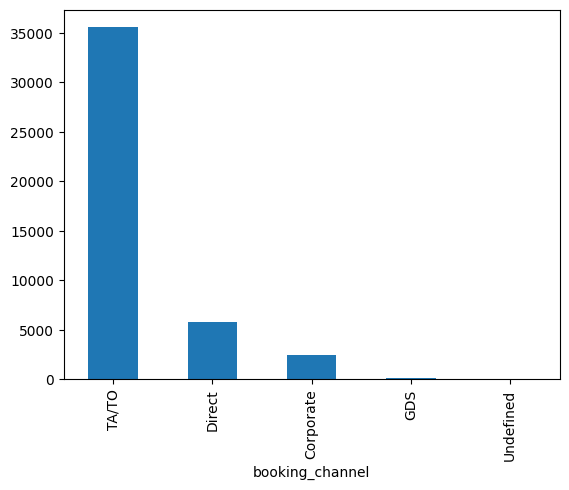

In [149]:
dfcl["booking_channel"].value_counts().plot(kind="bar")

In [151]:
dfcl["total_stay_nights"].describe()

dfcl.groupby("hotel_type")["total_stay_nights"].mean()

hotel_type
Luxury Resort    4.358387
Urban Hotel      3.012322
Name: total_stay_nights, dtype: float64

<Axes: ylabel='count'>

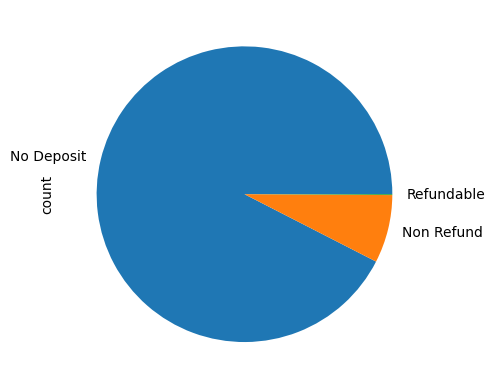

In [155]:
dfcl["deposit_type"].value_counts().plot(kind="pie")

In [158]:
dfcl["booking_season"].value_counts()

booking_season
Summer    14330
Spring    12040
Autumn    10223
Winter     7340
Name: count, dtype: int64

In [159]:
dfcl.loc[
    dfcl["booking_season"] == "Summer",
    "num_adults"
].value_counts()

num_adults
2    11408
1     1664
3     1258
Name: count, dtype: int64

In [160]:
dfcl["modifications"].describe()

count    43933.000000
mean         0.236223
std          0.655322
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         17.000000
Name: modifications, dtype: float64

In [163]:
dfcl["hotel_type"].value_counts()

hotel_type
Urban Hotel      28486
Luxury Resort    15447
Name: count, dtype: int64

In [171]:
dfcl.loc[(dfcl["hotel_type"]=="Urban Hotel")&(dfcl["booking_season"]=="Summer"),"num_adults"].value_counts()

num_adults
2    6983
1    1294
3     928
Name: count, dtype: int64

the number people who booked urban hotel in summer are couples are: 6983 and trio: 928 and single: 1294 

-so ye couple loved to come alot in summer and mainly in urban hotel hence it is better to increase the  accesability of hotel needs in favour of couples i guess
